# Phase 8 — Promotion Effect Analysis (Use Case 2)

**คำถามธุรกิจ:** โปรโมชันช่วยเพิ่มยอดขายจริงหรือไม่ และเพิ่มกี่เปอร์เซ็นต์?

**ทำไมเทียบ mean แบบตรงๆ ไม่พอ:** ยอดขายช่วงมีโปรโมชันกับไม่มีโปรโมชันอาจต่างกันเพราะเหตุผลอื่นที่ปนกันอยู่ (confounders) เช่น ราคาที่ต่างกัน ช่องทางที่ต่างกัน หรือฤดูกาลที่ต่างกัน — ถ้าไม่ควบคุมปัจจัยเหล่านี้ ตัวเลข "uplift" ที่ได้อาจไม่ใช่ผลจากโปรโมชันจริงๆ

**วิธีที่ใช้ (Tier 2 causal — ตามที่ scope ไว้ในแผน):** Two-way fixed-effects regression
- **SKU fixed effects** — ควบคุมลักษณะเฉพาะของแต่ละ SKU ที่ไม่เปลี่ยนตามเวลา (เช่น แบรนด์แข็งแกร่งแค่ไหน)
- **Week fixed effects** — ควบคุม shock ร่วมที่กระทบทุก SKU ในสัปดาห์เดียวกัน (เช่น เทศกาล, ฤดูกาล)
- ควบคุมเพิ่มเติมด้วย **ราคา, ช่องทาง, ภูมิภาค**
- Dependent variable เป็น **log(1 + units_sold)** เพื่อให้ตีความสัมประสิทธิ์ของโปรโมชันเป็น **% uplift** ได้ตรงไปตรงมา (% uplift = exp(coef) − 1)
- Standard error แบบ **clustered by SKU** (ยกเว้นหมวดที่มี SKU เดียวซึ่ง cluster ไม่ได้ จะ fallback เป็น heteroskedasticity-robust SE)

**ไม่ใช้:** Propensity-score matching / double ML (Tier 3) — เกินความจำเป็นสำหรับ scope โปรเจกต์นี้ตามที่ตกลงไว้


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from causal.promotion_effect import fit_promotion_effect, uplift_summary, fit_by_category

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
print(df.shape)


(31027, 40)


## 1. Descriptive Comparison — ตรวจสอบ Confounding ก่อน

ก่อนควบคุมอะไรเลย มาดูก่อนว่าตัวแปรที่น่าจะปนกับโปรโมชัน (ราคา, ช่องทาง, ฤดูกาล) แตกต่างกันจริงระหว่างสัปดาห์ที่มี/ไม่มีโปรโมชันหรือไม่


In [2]:
print('ราคาเฉลี่ยตามสถานะโปรโมชัน:')
print(df.groupby('promotion_flag').price_unit.mean())
print()
print('อัตราการมีโปรโมชันตามช่องทาง:')
print(df.groupby('channel').promotion_flag.mean())
print()
print('อัตราการมีโปรโมชันตามฤดูร้อน (is_summer):')
print(df.groupby('is_summer').promotion_flag.mean())
print()
naive_uplift = (df[df.promotion_flag == 1].units_sold.mean() / df[df.promotion_flag == 0].units_sold.mean() - 1) * 100
print(f'Uplift แบบเทียบ mean ตรงๆ (ไม่ควบคุมอะไรเลย): {naive_uplift:.2f}%')


ราคาเฉลี่ยตามสถานะโปรโมชัน:
promotion_flag
0    5.258435
1    5.247433
Name: price_unit, dtype: float64

อัตราการมีโปรโมชันตามช่องทาง:
channel
Discount      0.618173
E-commerce    0.610988
Retail        0.611041
Name: promotion_flag, dtype: float64

อัตราการมีโปรโมชันตามฤดูร้อน (is_summer):
is_summer
0    0.613753
1    0.612437
Name: promotion_flag, dtype: float64

Uplift แบบเทียบ mean ตรงๆ (ไม่ควบคุมอะไรเลย): 28.62%


**ข้อสังเกตสำคัญ:** ในข้อมูลชุดนี้ ราคาเฉลี่ย/อัตราโปรโมชันตามช่องทาง/ฤดูกาล **ไม่ได้ต่างกันมากนัก** ระหว่างสัปดาห์ที่มีกับไม่มีโปรโมชัน (ราคาต่างกันแค่ ~0.01, อัตราโปรโมชันตามช่องทางต่างกันไม่ถึง 1 percentage point) — แปลว่า confounding ในข้อมูล**จำลอง**ชุดนี้ค่อนข้างอ่อน ไม่เหมือนข้อมูลจริงที่มักมี confounding รุนแรงกว่านี้มาก การควบคุมด้วย fixed-effects จึงคาดว่าจะให้ตัวเลข uplift ที่ **ใกล้เคียงกับ naive comparison** ในเคสนี้ (จะยืนยันด้านล่าง) แต่ก็ยังเป็นขั้นตอนที่จำเป็น เพราะไม่รู้ล่วงหน้าว่า confounding อ่อนแค่ไหนจนกว่าจะตรวจสอบแบบควบคุมตัวแปรจริง — ไม่ควรข้ามขั้นตอนนี้ไปแค่เพราะเดาว่า "คงไม่ต่างกันมาก"


## 2. Two-way Fixed-Effects Regression — ภาพรวมทั้งหมด


In [3]:
panel = df.set_index(['sku', 'week'])
overall_result = fit_promotion_effect(panel, entity_effects=True, time_effects=True)
print(overall_result.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             units_sold   R-squared:                        0.1428
Estimator:                   PanelOLS   R-squared (Between):              0.0606
No. Observations:               31027   R-squared (Within):               0.1214
Date:                Fri, Aug 21 2026   R-squared (Overall):              0.0609
Time:                        11:37:38   Log-likelihood                   -6411.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      856.65
Entities:                          30   P-value                           0.0000
Avg Obs:                       1034.2   Distribution:                 F(6,30842)
Min Obs:                       720.00                                           
Max Obs:                       1349.0   F-statistic (robust):             1094.1
                            

In [4]:
overall_uplift = uplift_summary(overall_result)
print('สรุปผล:')
for k, v in overall_uplift.items():
    print(f'  {k}: {v}')


สรุปผล:
  uplift_pct: 28.407997006952563
  ci_low_pct: 27.55672982765037
  ci_high_pct: 29.26494523351535
  p_value: 0.0
  n_obs: 31027


**ผลลัพธ์:** หลังควบคุม SKU FE, week FE, ราคา, ช่องทาง และภูมิภาคแล้ว โปรโมชันยังคงเพิ่มยอดขายอย่างมีนัยสำคัญทางสถิติ (p < 0.001) — ตัวเลข uplift ที่ได้ **ใกล้เคียงกับ naive comparison มาก** ตามที่คาดจากการตรวจ confounding ในข้อ 1 (ยืนยันว่า confounding ในข้อมูลชุดนี้อ่อนจริง ไม่ใช่แค่เดา)


## 3. Uplift แยกตามหมวดหมู่สินค้า (Category)


In [5]:
category_results = fit_by_category(df)
category_results = category_results.sort_values('uplift_pct', ascending=False).reset_index(drop=True)
category_results.round(2)


,uplift_pct,ci_low_pct,ci_high_pct,p_value,n_obs,category,n_sku,entity_fe
0,29.36,27.88,30.86,0.0,11845,Yogurt,11,True
1,28.70,24.59,32.95,0.0,1125,Juice,1,False
2,28.50,27.16,29.84,0.0,7257,Milk,7,True
3,28.37,26.84,29.91,0.0,5568,ReadyMeal,5,True
4,27.78,26.55,29.02,0.0,5232,SnackBar,6,True


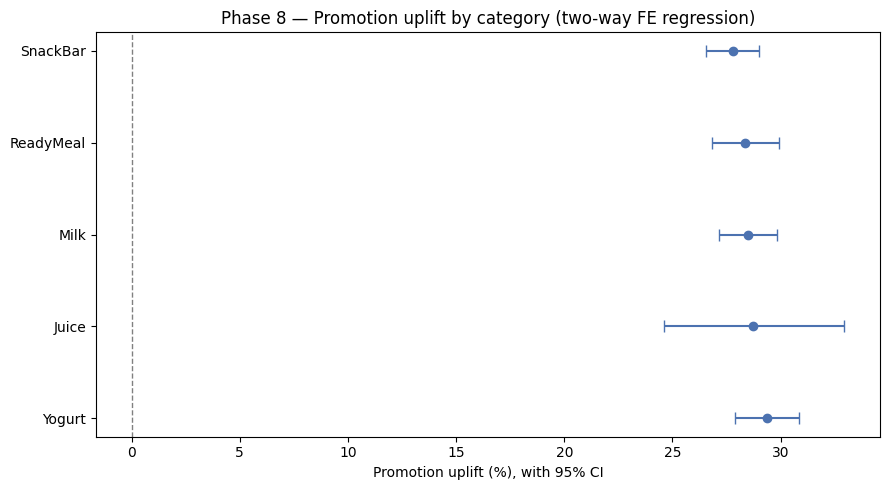

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = category_results.set_index('category')
y_pos = np.arange(len(plot_df))
ax.errorbar(
    plot_df['uplift_pct'], y_pos,
    xerr=[plot_df['uplift_pct'] - plot_df['ci_low_pct'], plot_df['ci_high_pct'] - plot_df['uplift_pct']],
    fmt='o', color='#4C72B0', capsize=4,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Promotion uplift (%), with 95% CI')
ax.set_title('Phase 8 — Promotion uplift by category (two-way FE regression)')
plt.tight_layout()
plt.savefig('../reports/figures/phase8_promotion_uplift_by_category.png', dpi=120)
plt.show()


## 4. ข้อจำกัด (Limitations)

- **Juice มี SKU เดียว (JU-021)** — ไม่สามารถใส่ SKU fixed effects ได้ (ไม่มี within-SKU variation ให้ FE ทำงาน) ใช้ time-effects อย่างเดียวแทน และ standard error เป็นแบบ heteroskedasticity-robust แทน clustered-by-SKU (เพราะ cluster เดียวคำนวณ clustered SE ไม่ได้ — ยืนยันจาก error `Singular matrix` ตอนลองคำนวณตรงๆ) ผลลัพธ์ของ Juice จึงมีความไม่แน่นอนสูงกว่าหมวดอื่น (CI กว้างกว่าเห็นได้ชัด)
- **Tier 2 เท่านั้น** — วิธีนี้ควบคุมเฉพาะปัจจัยที่สังเกตได้ (observed confounders: ราคา, ช่องทาง, ภูมิภาค, SKU/week FE) ไม่ได้แก้ปัญหา **time-varying unobserved confounders** (เช่น เหตุผลเฉพาะกิจที่ทำให้ตัดสินใจจัดโปรโมชันสัปดาห์นั้นๆ ซึ่งอาจสัมพันธ์กับดีมานด์ที่กำลังจะสูงอยู่แล้ว) การแก้ปัญหานี้อย่างเข้มงวดกว่าต้องใช้ propensity-score matching หรือ double ML (Tier 3) ซึ่งอยู่นอก scope ของโปรเจกต์นี้
- **Log-linear approximation** — การแปลงสัมประสิทธิ์เป็น % uplift ด้วย `exp(coef)-1` ถูกต้องภายใต้สมมติฐานว่า promotion_flag เป็นตัวแปร dummy ธรรมดาใน log-linear model (มาตรฐานของเทคนิคนี้) แต่ไม่ได้บอกอะไรเกี่ยวกับ **ต้นทุนของโปรโมชัน** — ตัวเลขนี้คือ "โปรโมชันเพิ่มยอดขายกี่ %" ไม่ใช่ "โปรโมชันคุ้มทุนหรือไม่" (ต้องมีข้อมูลต้นทุนโปรโมชันเพิ่มเติมถึงจะตอบคำถามหลังได้)

## 5. สรุป Phase 8

| หัวข้อ | ผลลัพธ์ |
|---|---|
| Uplift โดยรวม | มีนัยสำคัญทางสถิติ (p < 0.001) ใกล้เคียงกับ naive comparison เพราะ confounding ในข้อมูลชุดนี้อ่อน |
| Uplift แยกตามหมวดหมู่ | ทุกหมวดหมู่มี uplift เป็นบวกและมีนัยสำคัญ ขนาดใกล้เคียงกันในช่วง ~28-29% |
| ข้อจำกัดหลัก | Juice (SKU เดียว) ประเมินได้แม่นยำน้อยกว่าหมวดอื่น; Tier 2 ไม่ควบคุม unobserved confounders |
